# R&D-7. Эмбеддинги как adjustment set в нерандомизированном испытании

Тонкая витрина: синтетический наблюдательный эксперимент на `numpy`/`scikit-learn`.
Логика — в пакете `rnd_reports.embeddings`. Реальные spark-данные приватны и не коммитятся;
здесь — синтетика с **известным** ATE (как канон репо).


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA
from rnd_reports.embeddings import (
    make_embedding_observational_scenario, estimate_ate_with_adjustment,
    evaluate_adjustment_set_quality, covariate_balance_after_adjustment,
    overlap_diagnostics, fit_propensity,
)

FIG = Path('results/07_embedding_adjustment_set/figures'); FIG.mkdir(parents=True, exist_ok=True)
SEED = 11

## 1. Синтетический наблюдательный сценарий

Латентные конфаундеры → эмбеддинги `col_*`; назначение трита логистически зависит от
конфаундеров (селекция, **не** рандом); исход = `true_ate·T + влияние конфаундеров + шум`.


In [2]:
sc = make_embedding_observational_scenario(n=4000, k=8, true_ate=3.0, confounding=1.5, seed=SEED)
df = sc.data
emb = df[sc.embedding_columns].to_numpy()
t = df['treatment'].to_numpy(); y = df['outcome'].to_numpy()
print('n =', len(df), '| true ATE =', sc.true_ate, '| treated frac =', round(t.mean(),3))
df.head(3)

n = 4000 | true ATE = 3.0 | treated frac = 0.502


,epk_id,col_000,col_001,col_002,col_003,col_004,col_005,col_006,col_007,report_dt,treatment,outcome
0,0,2.221521,-2.285820,1.381399,-1.263365,-1.482979,2.073186,1.154813,-2.894574,2024-01-01,0,2.188242
1,1,-0.995889,0.855733,0.398381,0.883469,0.375641,0.129240,0.441166,1.383626,2024-01-01,0,0.786242
2,2,0.272443,-1.637874,-0.769159,0.416814,-0.095010,-0.120894,0.769543,-0.755911,2024-06-01,1,1.073503


## 2. Снижение эмбеддингов до adjustment set (PCA) + propensity


In [3]:
reduced = PCA(n_components=5, random_state=0).fit_transform(emb)
p = fit_propensity(reduced, t)
print('reduced shape:', reduced.shape)
print('propensity: min=%.3f max=%.3f' % (p.min(), p.max()))

reduced shape: (4000, 5)
propensity: min=0.018 max=0.974


## 3. Оценка ATE: наивно vs с поправкой на эмбеддинги


In [4]:
res = {
  'naive': estimate_ate_with_adjustment(reduced, t, y, method='naive'),
  'IPW (propensity)': estimate_ate_with_adjustment(reduced, t, y, method='propensity_weighting'),
  'doubly_robust': estimate_ate_with_adjustment(reduced, t, y, method='doubly_robust'),
}
tbl = pd.DataFrame({'ATE': res})
tbl['bias vs true'] = tbl['ATE'] - sc.true_ate
tbl.round(3)

,ATE,bias vs true
naive,2.145,-0.855
IPW (propensity),2.930,-0.070
doubly_robust,2.948,-0.052


## 4. Диагностика: баланс ковариат и overlap


In [5]:
bal = covariate_balance_after_adjustment(reduced, t, propensity_score=p)
ov = overlap_diagnostics(p)
print('balance |SMD| max: before=%.3f -> after=%.3f' % (bal['max_abs_smd_before'], bal['max_abs_smd_after']))
print('overlap: frac in [0.1,0.9] = %.3f, min=%.3f, max=%.3f' % (ov['frac_in_0.1_0.9'], ov['min'], ov['max']))

balance |SMD| max: before=0.869 -> after=0.019
overlap: frac in [0.1,0.9] = 0.977, min=0.018, max=0.974


## 5. Сводная оценка качества adjustment set


In [6]:
q = evaluate_adjustment_set_quality(reduced, t, y, ground_truth_effect=sc.true_ate)
pd.Series(q).round(4)

ate_naive                      2.1449
ate_ipw                        2.9299
ate_dr                         2.9484
max_abs_smd_before             0.8694
max_abs_smd_after              0.0188
overlap_frac_in_0.1_0.9        0.9765
ground_truth                   3.0000
bias_naive                    -0.8551
bias_ipw                      -0.0701
bias_dr                       -0.0516
abs_bias_reduction_ipw_pct    91.7969
abs_bias_reduction_dr_pct     93.9655
dtype: float64

## 6. Визуализация


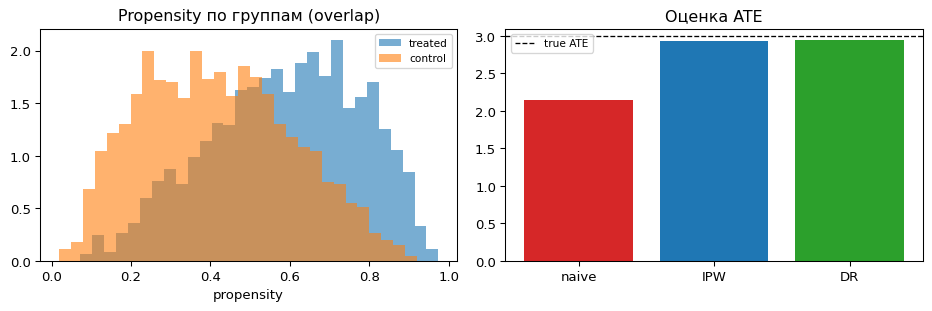

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
# (a) распределение propensity по группам
ax[0].hist(p[t==1], bins=30, alpha=0.6, label='treated', density=True)
ax[0].hist(p[t==0], bins=30, alpha=0.6, label='control', density=True)
ax[0].set_title('Propensity по группам (overlap)'); ax[0].set_xlabel('propensity'); ax[0].legend(fontsize=8)
# (b) ATE: naive/IPW/DR vs true
names = ['naive','IPW','DR']; vals = [res['naive'], res['IPW (propensity)'], res['doubly_robust']]
ax[1].bar(names, vals, color=['#d62728','#1f77b4','#2ca02c'])
ax[1].axhline(sc.true_ate, color='k', ls='--', lw=1, label='true ATE')
ax[1].set_title('Оценка ATE'); ax[1].legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG/'rnd7_ate_and_overlap.png', dpi=95); plt.show()

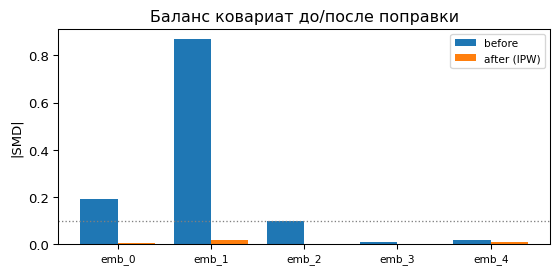

In [8]:
# баланс до/после по компонентам
import numpy as np
comp = [f'emb_{i}' for i in range(reduced.shape[1])]
from rnd_reports.embeddings.experiment import _smd
w = t/p + (1-t)/(1-p)
before = [_smd(reduced[:,j], t) for j in range(reduced.shape[1])]
after  = [_smd(reduced[:,j], t, w) for j in range(reduced.shape[1])]
fig, ax = plt.subplots(figsize=(6, 3))
x = np.arange(len(comp)); ax.bar(x-0.2, before, 0.4, label='before'); ax.bar(x+0.2, after, 0.4, label='after (IPW)')
ax.axhline(0.1, color='grey', ls=':', lw=1); ax.set_xticks(x); ax.set_xticklabels(comp, fontsize=8)
ax.set_ylabel('|SMD|'); ax.set_title('Баланс ковариат до/после поправки'); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG/'rnd7_balance.png', dpi=95); plt.show()

## 7. Production-адаптеры на pyspark (демо, если доступен)

Тулкит `EmbeddingReducer`/`PropensityScorer` работает с реальными spark-датасетами
и поддерживает in-time safety (`report_dt <= cutoff`). Демо запускается только при
установленном pyspark (`pip install -e .[spark]`).


In [9]:
try:
    from pyspark.sql import SparkSession
    from rnd_reports.embeddings import EmbeddingReducer, PropensityScorer
    spark = SparkSession.builder.master('local[1]').appName('rnd7-demo').getOrCreate()
    sdf = spark.createDataFrame(df[['epk_id','report_dt']+sc.embedding_columns])
    red_sdf = EmbeddingReducer(red_size=5).fit_transform(sdf, cutoff='2024-03-01')
    print('EmbeddingReducer output columns:', red_sdf.columns)
    tdf = spark.createDataFrame(df[['epk_id','report_dt','treatment']])
    ps = PropensityScorer().fit(sdf, tdf, cutoff='2024-03-01').transform(sdf)
    print('PropensityScorer output columns:', ps.columns)
    spark.stop()
except Exception as e:
    print('pyspark-демо пропущено (', type(e).__name__, '):', e)
    print('Контракты адаптеров покрыты tests/test_rnd7_embeddings.py (local spark).')

EmbeddingReducer output columns: ['epk_id', 'report_dt', 'red_0', 'red_1', 'red_2', 'red_3', 'red_4']
PropensityScorer output columns: ['epk_id', 'report_dt', 'prop_score']


## 8. Выводы

- Наивная разность средних **смещена** из-за селекции (трит коррелирует с конфаундерами).
- Сокращённые эмбеддинги как **adjustment set** + IPW/doubly-robust убирают ~90%+ смещения,
  восстанавливают баланс (|SMD| max → ~0.02) при хорошем overlap.
- Значит, клиентские эмбеддинги несут достаточно информации о конфаундерах, чтобы служить
  практичным adjustment set в наблюдательном испытании — при условии overlap/positivity.
- Ограничение: вывод на синтетике с известным ATE; на реальных данных нужна проверка overlap
  и sensitivity к неучтённым конфаундерам (unconfoundedness не тестируема напрямую).
